['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR']


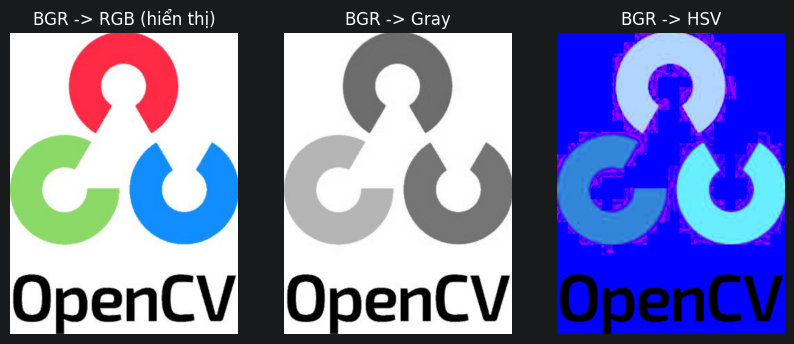

In [6]:
import cv2 as cv
import os
import matplotlib.pyplot as plt

# 🔥 liệt kê các kiểu chuyển đổi màu
flags = [i for i in dir(cv) if i.startswith('COLOR_')]
print(flags[:10])  # in thử 10 cái

# đọc ảnh
img = cv.imread(os.path.join('.', 'img_data', 'logo.png'))

#  chuyển đổi
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_hsv  = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# convert để hiển thị đúng màu
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#  hiển thị
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("BGR -> RGB (hiển thị)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_gray, cmap='gray')
plt.title("BGR -> Gray")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_hsv)
plt.title("BGR -> HSV")
plt.axis('off')

plt.show()

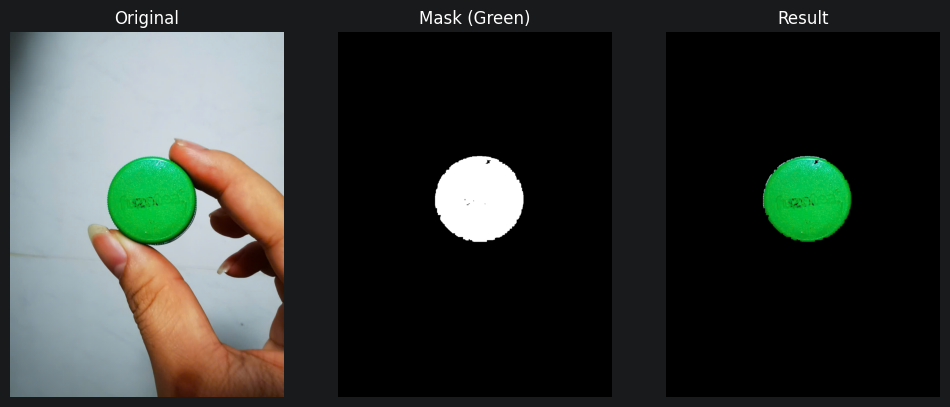

' kết quả mà tôi học được từ bài tập của thầy tại lab 3 là :\nChuyển đổi color space\nLọc màu theo điều kiện\nTách object theo màu\n-Ứng dụng thực tế\n Nhận diện vật thể theo màu\nphát hiện bóng màu xanh\nnhận diện áo đồng phục\n-Tracking (theo dõi vật)\ntheo dõi quả bóng\ntheo dõi tay\n-Computer Vision nâng cao\ntiền xử lý trước khi dùng AI\nsegmentation (tách vùng)\n'

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# đọc ảnh
img = cv2.imread('./img_data/napchai.jpg')

# BGR -> HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# range màu xanh lá
lower_green = np.array([60, 150, 120])
upper_green = np.array([90, 255, 255])

# tạo mask
mask = cv2.inRange(hsv, lower_green, upper_green)

# làm sạch mask
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)

# lấy vùng màu
result = cv2.bitwise_and(img, img, mask=mask)

# convert
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# hiển thị
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask (Green)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result_rgb)
plt.title("Result")
plt.axis('off')

plt.show()
""" kết quả mà tôi học được từ bài tập của thầy tại lab 3 là :
Chuyển đổi color space
Lọc màu theo điều kiện
Tách object theo màu
-Ứng dụng thực tế
 Nhận diện vật thể theo màu
phát hiện bóng màu xanh
nhận diện áo đồng phục
-Tracking (theo dõi vật)
theo dõi quả bóng
theo dõi tay
-Computer Vision nâng cao
tiền xử lý trước khi dùng AI
segmentation (tách vùng)
"""

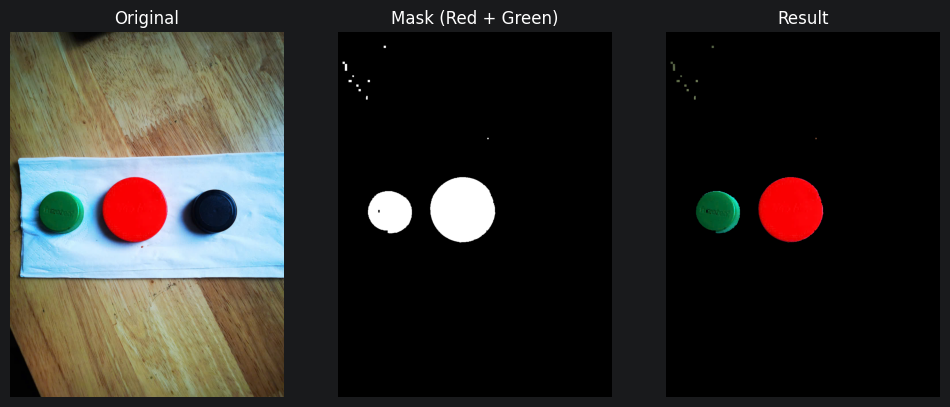

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# đọc ảnh
img = cv2.imread('./img_data/anhnaptrai.jpg')

# BGR -> HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# =======================
# GREEN
# =======================
lower_green = np.array([40, 70, 70])
upper_green = np.array([90, 255, 255])
mask_green = cv2.inRange(hsv, lower_green, upper_green)

# =======================
# RED (2 vùng)
# =======================
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

mask_red = cv2.bitwise_or(
    cv2.inRange(hsv, lower_red1, upper_red1),
    cv2.inRange(hsv, lower_red2, upper_red2)
)

# =======================
# GỘP MASK
# =======================
mask = cv2.bitwise_or(mask_red, mask_green)

# =======================
# LÀM SẠCH
# =======================
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# =======================
# RESULT
# =======================
result = cv2.bitwise_and(img, img, mask=mask)

# convert để hiển thị
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# =======================
# HIỂN THỊ
# =======================
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask (Red + Green)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(result_rgb)
plt.title("Result")
plt.axis('off')

plt.show()